In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier, BaggingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, r2_score, mean_absolute_error

from sklearn.preprocessing import StandardScaler

import numpy as np
np.random.seed(42)

from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression, RFE
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, Isomap


In [127]:
bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=6, random_state=42), 
    n_estimators=50, 
    random_state=42
)

def test_classification(X, y, label=""):
    print(f"Классификация: {label} ")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)
    
    bag = BaggingClassifier(random_state=42).fit(X_train, y_train)
    preds = bag.predict(X_test)
    print(classification_report(y_test, preds, zero_division=0))

def test_regression(X, y, label=""):
    print(f"Регрессия: {label}")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=True)
    
    bag = BaggingRegressor(random_state=42).fit(X_train, y_train)
    preds = bag.predict(X_test)
    print(f"R2 Score: {r2_score(y_test, preds):.4f} | MAE: {mean_absolute_error(y_test, preds):.4f}\n")

In [105]:
df_class = pd.read_csv("../csv/cl_finished.csv", sep=";")
X_cl = df_class.drop(columns="Diabetes_012")
y_cl = df_class["Diabetes_012"]

df_reg = pd.read_csv("../csv/winequality_finished.csv", sep=";")
X_reg = df_reg.drop(columns = "quality")
y_reg = df_reg["quality"]

In [106]:
scaler = StandardScaler()
X_cl_scaled = pd.DataFrame(scaler.fit_transform(X_cl), columns=X_cl.columns)
X_reg_scaled = pd.DataFrame(scaler.fit_transform(X_reg), columns=X_reg.columns)

X_cl_sampled = X_cl_scaled.iloc[:10000]
y_cl_sampled = y_cl.iloc[:10000]
X_cl_sampled_tsne = X_cl_scaled.iloc[:3000]
y_cl_sampled_tsne = y_cl.iloc[:3000]

# Отбор для классификации

In [107]:
test_classification(X_cl, y_cl)

Классификация:  
              precision    recall  f1-score   support

           0       0.85      0.94      0.89     28603
           1       0.02      0.00      0.01       683
           2       0.39      0.22      0.28      5182

    accuracy                           0.81     34468
   macro avg       0.42      0.39      0.39     34468
weighted avg       0.77      0.81      0.78     34468



## VarianceThreshold

In [108]:
X_cl.var()

HighBP                   0.247925
HighChol                 0.246609
CholCheck                0.038827
BMI                     46.054687
Smoker                   0.248822
Stroke                   0.042753
HeartDiseaseorAttack     0.092563
PhysActivity             0.195546
Fruits                   0.237240
Veggies                  0.163086
HvyAlcoholConsump        0.057025
AnyHealthcare            0.051018
NoDocbcCost              0.084197
GenHlth                  1.133555
MentHlth                59.501552
PhysHlth                81.840386
DiffWalk                 0.151095
Sex                      0.246308
Age                      9.571653
Education                0.985840
Income                   4.378462
dtype: float64

In [109]:
X_cl.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,229781.000000,229781.000000,229781.000000,229781.00000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,...,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000
mean,0.454441,0.441760,0.959535,28.68567,0.465661,0.044756,0.103216,0.733355,0.612966,0.794813,...,0.946075,0.092810,2.601151,3.505373,4.675178,0.185507,0.439231,8.086582,4.980568,5.890383
std,0.497921,0.496598,0.197047,6.78636,0.498821,0.206767,0.304241,0.442206,0.487073,0.403839,...,0.225871,0.290167,1.064685,7.713725,9.046568,0.388709,0.496295,3.093809,0.992895,2.092477
min,0.000000,0.000000,0.000000,12.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,1.000000,24.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,1.000000,27.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,32.00000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,4.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,98.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [ ]:
cl_vt = VarianceThreshold(0.02)
X_cl_vt = cl_vt.fit_transform(X_cl)
X_cl_vt = pd.DataFrame(X_cl_vt, columns=cl_vt.get_feature_names_out())
print(X_cl_vt.shape)

print(f"Отобранные признаки: {list(X_cl_vt.columns)}")
test_classification(X_cl_vt, y_cl)

(229781, 21)
[RFE] Отобранные признаки: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
Классификация:  
              precision    recall  f1-score   support

           0       0.85      0.94      0.89     28603
           1       0.02      0.00      0.01       683
           2       0.39      0.22      0.28      5182

    accuracy                           0.81     34468
   macro avg       0.42      0.39      0.39     34468
weighted avg       0.77      0.81      0.78     34468



## SelectKBest

In [ ]:
skb_cl = SelectKBest(score_func=f_classif, k=12)
X_cl_skb = skb_cl.fit_transform(X_cl, y_cl)
X_cl_skb = pd.DataFrame(X_cl_skb, columns=skb_cl.get_feature_names_out())

print(f"Отобранные признаки: {list(X_cl_skb.columns)}")
test_classification(X_cl_skb, y_cl)

[SelectKBest] Отобранные признаки: ['HighBP', 'HighChol', 'BMI', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'GenHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income']
Классификация:  
              precision    recall  f1-score   support

           0       0.85      0.93      0.89     28603
           1       0.01      0.00      0.00       683
           2       0.37      0.24      0.29      5182

    accuracy                           0.80     34468
   macro avg       0.41      0.39      0.39     34468
weighted avg       0.77      0.80      0.78     34468



## RFE

In [ ]:
estim = DecisionTreeClassifier().fit(X_cl, y_cl)
rfe_cl = RFE(estimator=estim, n_features_to_select=12, step=1).fit(X_cl, y_cl)
X_cl_rfe = pd.DataFrame(rfe_cl.transform(X_cl), columns=rfe_cl.get_feature_names_out())

print(f"Отобранные признаки: {list(X_cl_rfe.columns)}")
test_classification(X_cl_rfe, y_cl)

[RFE] Отобранные признаки: ['HighBP', 'BMI', 'Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
Классификация:  
              precision    recall  f1-score   support

           0       0.85      0.93      0.89     28603
           1       0.01      0.00      0.00       683
           2       0.36      0.21      0.26      5182

    accuracy                           0.80     34468
   macro avg       0.40      0.38      0.39     34468
weighted avg       0.76      0.80      0.78     34468



## PCA

In [113]:
pca_cl = PCA(n_components=12, random_state=42)
X_cl_pca = pca_cl.fit_transform(X_cl_scaled)
test_classification(X_cl_pca, y_cl, "PCA")

Классификация: PCA 
              precision    recall  f1-score   support

           0       0.85      0.95      0.90     28603
           1       0.02      0.00      0.00       683
           2       0.42      0.19      0.26      5182

    accuracy                           0.82     34468
   macro avg       0.43      0.38      0.39     34468
weighted avg       0.77      0.82      0.79     34468



## KernelPCA (poly, rbf, sigmoid)

In [114]:
for kernel in ['poly', 'rbf', 'sigmoid']:
    kpca_cl = KernelPCA(n_components=5, kernel=kernel, n_jobs=-1, random_state=42)
    X_cl_kpca = kpca_cl.fit_transform(X_cl_sampled)
    test_classification(X_cl_kpca, y_cl_sampled, f"KernelPCA ({kernel})")

Классификация: KernelPCA (poly) 
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1267
           1       0.00      0.00      0.00        27
           2       0.36      0.19      0.25       206

    accuracy                           0.83      1500
   macro avg       0.41      0.38      0.38      1500
weighted avg       0.78      0.83      0.80      1500

Классификация: KernelPCA (rbf) 
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1267
           1       0.00      0.00      0.00        27
           2       0.36      0.19      0.25       206

    accuracy                           0.83      1500
   macro avg       0.41      0.38      0.38      1500
weighted avg       0.78      0.83      0.80      1500

Классификация: KernelPCA (sigmoid) 
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1267
           1       0.00     

## t-SNE

In [115]:
tsne_cl = TSNE(n_components=3, random_state=42, n_jobs=-1)
X_cl_tsne = tsne_cl.fit_transform(X_cl_sampled_tsne)
test_classification(X_cl_tsne, y_cl_sampled_tsne, "t-SNE")

Классификация: t-SNE 
              precision    recall  f1-score   support

           0       0.81      0.93      0.86       353
           1       0.00      0.00      0.00         7
           2       0.38      0.18      0.24        90

    accuracy                           0.77       450
   macro avg       0.40      0.37      0.37       450
weighted avg       0.71      0.77      0.73       450



## Isomap

In [116]:
iso_cl = Isomap(n_components=5, n_jobs=-1)
X_cl_iso = iso_cl.fit_transform(X_cl_sampled)
test_classification(X_cl_iso, y_cl_sampled, "Isomap")

Классификация: Isomap 
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1267
           1       0.00      0.00      0.00        27
           2       0.34      0.15      0.20       206

    accuracy                           0.83      1500
   macro avg       0.40      0.37      0.37      1500
weighted avg       0.77      0.83      0.79      1500



## UMAP

In [117]:
umap_cl = umap.UMAP(n_components=5, random_state=42, n_jobs=-1)
X_cl_umap = umap_cl.fit_transform(X_cl_sampled)
test_classification(X_cl_umap, y_cl_sampled, "UMAP")

C:\Users\zuzin\AppData\Roaming\Python\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Классификация: UMAP 
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1267
           1       0.20      0.04      0.06        27
           2       0.34      0.19      0.24       206

    accuracy                           0.82      1500
   macro avg       0.47      0.39      0.40      1500
weighted avg       0.78      0.82      0.79      1500



# Отбор для регрессии

In [128]:
test_regression(X_reg, y_reg, "Исходные данные")

Регрессия: Исходные данные
R2 Score: 0.4335 | MAE: 0.4723



## VarianceThreshold

In [129]:
reg_vt = VarianceThreshold(threshold=0.02)
X_reg_vt = pd.DataFrame(reg_vt.fit_transform(X_reg), columns=reg_vt.get_feature_names_out())
print(f"Отобранные признаки: {list(X_reg_vt.columns)}")
test_regression(X_reg_vt, y_reg, "VarianceThreshold")

Отобранные признаки: ['red', 'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol']
Регрессия: VarianceThreshold
R2 Score: 0.4287 | MAE: 0.4721



## SelectKBest

In [130]:
skb_reg = SelectKBest(score_func=f_regression, k=7)
X_reg_skb = pd.DataFrame(skb_reg.fit_transform(X_reg, y_reg), columns=skb_reg.get_feature_names_out())
print(f"Отобранные признаки: {list(X_reg_skb.columns)}")
test_regression(X_reg_skb, y_reg, "SelectKBest")

Отобранные признаки: ['red', 'fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'density', 'alcohol']
Регрессия: SelectKBest
R2 Score: 0.3972 | MAE: 0.5101



## RFE

In [131]:
estim_reg = DecisionTreeRegressor(random_state=42).fit(X_reg, y_reg)
rfe_reg = RFE(estimator=estim_reg, n_features_to_select=7, step=1).fit(X_reg, y_reg)
X_reg_rfe = pd.DataFrame(rfe_reg.transform(X_reg), columns=rfe_reg.get_feature_names_out())
print(f"Отобранные признаки: {list(X_reg_rfe.columns)}")
test_regression(X_reg_rfe, y_reg, "RFE")

Отобранные признаки: ['volatile acidity', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'sulphates', 'alcohol']
Регрессия: RFE
R2 Score: 0.4985 | MAE: 0.4364



## PCA

In [132]:
pca_reg = PCA(n_components=7, random_state=42)
X_reg_pca = pca_reg.fit_transform(X_reg_scaled)
test_regression(X_reg_pca, y_reg, "PCA")

Регрессия: PCA
R2 Score: 0.4098 | MAE: 0.4715



## KernelPCA (poly, rbf, sigmoid)

In [133]:
for kernel in ['poly', 'rbf', 'sigmoid']:
    kpca_reg = KernelPCA(n_components=5, kernel=kernel, n_jobs=-1, random_state=42)
    X_reg_kpca = kpca_reg.fit_transform(X_reg_scaled)
    test_regression(X_reg_kpca, y_reg, f"KernelPCA ({kernel})")

Регрессия: KernelPCA (poly)
R2 Score: 0.3076 | MAE: 0.5042

Регрессия: KernelPCA (rbf)
R2 Score: 0.3790 | MAE: 0.5037

Регрессия: KernelPCA (sigmoid)
R2 Score: 0.3489 | MAE: 0.4825



## t-SNE

In [134]:
tsne_reg = TSNE(n_components=3, random_state=42, n_jobs=-1, perplexity=30)
X_reg_tsne = tsne_reg.fit_transform(X_reg_scaled)
test_regression(X_reg_tsne, y_reg, "t-SNE")

Регрессия: t-SNE
R2 Score: 0.4328 | MAE: 0.4585



## Isomap

In [135]:
iso_reg = Isomap(n_components=5, n_jobs=-1)
X_reg_iso = iso_reg.fit_transform(X_reg_scaled)
test_regression(X_reg_iso, y_reg, "Isomap")

C:\Users\zuzin\AppData\Roaming\Python\Python313\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 4 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\zuzin\AppData\Roaming\Python\Python313\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
C:\Users\zuzin\AppData\Roaming\Python\Python313\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
C:\Users\zuzin\AppData\Roaming\Python\Python313\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are mo

Регрессия: Isomap
R2 Score: 0.3204 | MAE: 0.4977



## UMAP

In [136]:
umap_reg = umap.UMAP(n_components=5, random_state=42, n_jobs=-1)
X_reg_umap = umap_reg.fit_transform(X_reg_scaled)
test_regression(X_reg_umap, y_reg, "UMAP")

C:\Users\zuzin\AppData\Roaming\Python\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Регрессия: UMAP
R2 Score: 0.3604 | MAE: 0.5042



In [137]:
class CustomPCA:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components = None
        self.mean = None

    def fit(self, X):
        
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        
        covariance_matrix = np.corrcoef(X_centered, rowvar=False) 
        
        eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
        
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        
        self.components = eigenvectors[:, :self.n_components]
        
    def transform(self, X):
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [145]:
class MyKMeans:
    def __init__(self, n_clusters, max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None

    def fit(self, X):
        np.random.seed(self.random_state)
        idx = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[idx].copy()

        for _ in range(self.max_iter):
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            self.labels_ = np.argmin(distances, axis=1)
            new_centroids = np.array([X[self.labels_ == k].mean(axis=0) for k in range(self.n_clusters)])
            if np.linalg.norm(new_centroids - self.centroids) < self.tol:
                break
            self.centroids = new_centroids
        return self

    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

In [138]:
pca = CustomPCA(n_components=2)
X_pca = pca.fit_transform(X_cl_scaled)

In [147]:
kmeans = MyKMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit(X_pca)

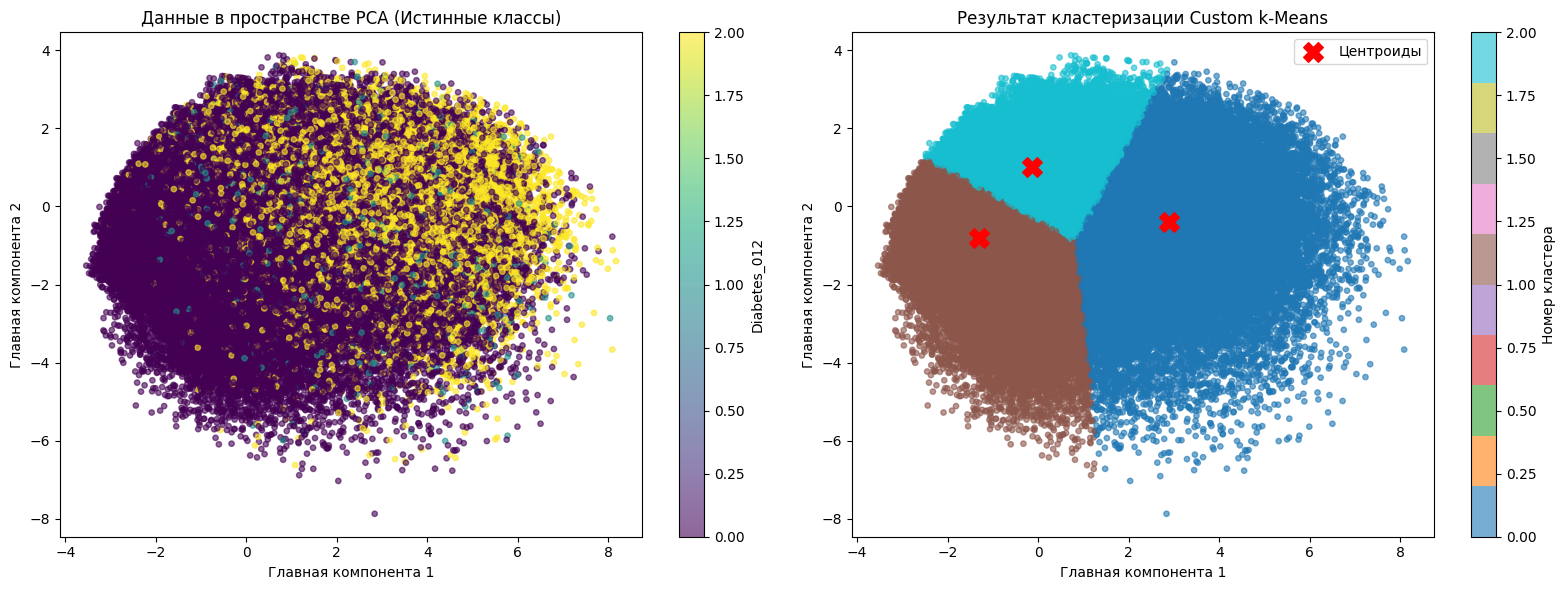

In [150]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_cl, cmap='viridis', alpha=0.6, s=15)
ax1.set_title("Данные в пространстве PCA (Истинные классы)")
ax1.set_xlabel("Главная компонента 1")
ax1.set_ylabel("Главная компонента 2")
fig.colorbar(scatter1, ax=ax1, label="Diabetes_012")

scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='tab10', alpha=0.6, s=15)

ax2.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c='red', marker='X', s=200, label='Центроиды')
ax2.set_title("Результат кластеризации Custom k-Means")
ax2.set_xlabel("Главная компонента 1")
ax2.set_ylabel("Главная компонента 2")
ax2.legend()
fig.colorbar(scatter2, ax=ax2, label="Номер кластера")

plt.tight_layout()
plt.show()